# Sentiment Analysis of Tweets using the Rnn

# Context:
There's a story behind every dataset and here's your opportunity to share yours.
training data was automatically created, as opposed to having humans manual annotate tweets. In our approach, we assume that any tweet with positive emoticons, like :), were positive, and tweets with negative emoticons, like :(, were negative.

In [1]:
import pandas as pd
import numpy as np

from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.utils import to_categorical
from keras.layers import Dense, SimpleRNN, Embedding, Flatten

c:\Users\Shaheen\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# load the dataset of twitter

In [3]:
train_ds = pd.read_csv("train.csv",encoding='latin1')
test_ds = pd.read_csv("test.csv",encoding='latin1')

In [5]:
train_ds.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


it is common to have a target variable (in this case, "sentiment") and input variables (in this case, "text") that are used for prediction or analysis. By extracting only these relevant columns, the code prepares the data sets for further modeling or analysis tasks.



In [7]:
train_ds = train_ds[['text', 'sentiment']]
test_ds = test_ds[['text', 'sentiment']]

By using this code, any missing values in the "text" column of the train_ds and test_ds data sets are filled with an empty string, ensuring that all data points have a value in the "text" column.

In [8]:
train_ds['text'].fillna('', inplace=True)
test_ds['text'].fillna('', inplace=True)

By applying the func function to the "sentiment" column of both data sets, the code replaces the original sentiment values with their corresponding numerical representations. This allows for easier analysis, modeling, or other computations that require numerical values.

In [9]:
def func(sentiment):
    if sentiment == 'positive':
        return 0;
    if sentiment == 'negative':
        return 1;
    else:
        return 2;

train_ds['sentiment'] = train_ds['sentiment'].apply(func)
test_ds['sentiment'] = test_ds['sentiment'].apply(func)


By converting the "text" and "sentiment" columns into NumPy arrays, the code prepares the data for further analysis, modeling, or processing tasks that require numerical arrays, such as training a machine learning model or performing numerical computations on the data.

In [11]:
x_train = np.array(train_ds['text'].tolist())
y_train = np.array(train_ds['sentiment'].tolist())
x_test = np.array(test_ds['text'].tolist())
y_test = np.array(test_ds['sentiment'].tolist())

x_train

array([' I`d have responded, if I were going',
       ' Sooo SAD I will miss you here in San Diego!!!',
       'my boss is bullying me...', ...,
       ' Yay good for both of you. Enjoy the break - you probably need it after such hectic weekend  Take care hun xxxx',
       ' But it was worth it  ****.',
       '   All this flirting going on - The ATG smiles. Yay.  ((hugs))'],
      dtype='<U159')

the code converts the target variables y_train and y_test from categorical values to a one-hot encoded binary matrix representation, enabling compatibility with certain machine learning algorithms or functions that require this format.

In [15]:
y_train = to_categorical(y_train, 3)
y_test = to_categorical(y_test, 3)

In [16]:
y_train

array([[0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       ...,
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.]], dtype=float32)

In [17]:
x_test

array(['Last session of the day  http://twitpic.com/67ezh',
       ' Shanghai is also really exciting (precisely -- skyscrapers galore). Good tweeps in China:  (SH)  (BJ).',
       'Recession hit Veronique Branquinho, she has to quit her company, such a shame!',
       ..., '', '', ''], dtype='<U148')

In [18]:
y_test

array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       ...,
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.]], dtype=float32)

# Tokenization

The Tokenizer class offers various methods and attributes that facilitate tasks such as tokenization, vectorization, and encoding of text data.

it imports the Tokenizer class from Keras and creates an instance of it, which will be used to tokenize and preprocess text data in subsequent steps of the program.

In [27]:
from keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=20000)


In [28]:
tokenizer.fit_on_texts(x_train)
tokenizer.fit_on_texts(x_test)

In [29]:
len(tokenizer.word_index)

28614

In [30]:
x_train = tokenizer.texts_to_sequences(x_train)
x_test = tokenizer.texts_to_sequences(x_test)

# RNN Model

The purpose of padding sequences to a fixed length is to ensure that the input data has consistent dimensions, which is often required for many machine learning algorithms or models to process the data correctly. It allows for efficient batch processing and uniform representation of variable-length sequences.

In [31]:
x_train = pad_sequences(x_train, padding='post', maxlen=35)
x_test = pad_sequences(x_test, padding='post', maxlen=35)

In [35]:
x_train[0]

array([   1,  162,   19, 7713,   71,    1,  151,   49,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0])

In [36]:
x_train.shape

(27481, 35)

# RNN Model:
The purpose of using this code is to define and configure a neural network model for a specific task, which appears to be a classification task with 3 classes. The model architecture includes an embedding layer to learn word representations, a recurrent layer to process sequential data, and a dense layer for the final classification. The model.summary() statement provides a summary of the model's architecture and parameter count.

In [39]:
model = Sequential()
model.add(Embedding(input_dim=20000, output_dim=5, input_length=35))
model.add(SimpleRNN(32,return_sequences=False))
model.add(Dense(3,activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 35, 5)             100000    
                                                                 
 simple_rnn (SimpleRNN)      (None, 32)                1216      
                                                                 
 dense (Dense)               (None, 3)                 99        
                                                                 
Total params: 101315 (395.76 KB)
Trainable params: 101315 (395.76 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [40]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# history of model for checking accuracy and validation

In [42]:
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
859/859 [==============================] - 11s 13ms/step - loss: 0.3803 - accuracy: 0.8651 - val_loss: 0.6750 - val_accuracy: 0.7425
Epoch 2/10
859/859 [==============================] - 11s 12ms/step - loss: 0.3337 - accuracy: 0.8865 - val_loss: 0.6959 - val_accuracy: 0.7431
Epoch 3/10
859/859 [==============================] - 11s 12ms/step - loss: 0.2990 - accuracy: 0.8982 - val_loss: 0.7771 - val_accuracy: 0.7454
Epoch 4/10
859/859 [==============================] - 11s 12ms/step - loss: 0.2746 - accuracy: 0.9064 - val_loss: 0.7847 - val_accuracy: 0.7414
Epoch 5/10
859/859 [==============================] - 11s 13ms/step - loss: 0.2503 - accuracy: 0.9190 - val_loss: 0.9077 - val_accuracy: 0.7296
Epoch 6/10
859/859 [==============================] - 11s 13ms/step - loss: 0.2199 - accuracy: 0.9296 - val_loss: 0.8462 - val_accuracy: 0.7344
Epoch 7/10
859/859 [==============================] - 11s 13ms/step - loss: 0.2021 - accuracy: 0.9344 - val_loss: 0.8897 - val_accuracy:

# History plot

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


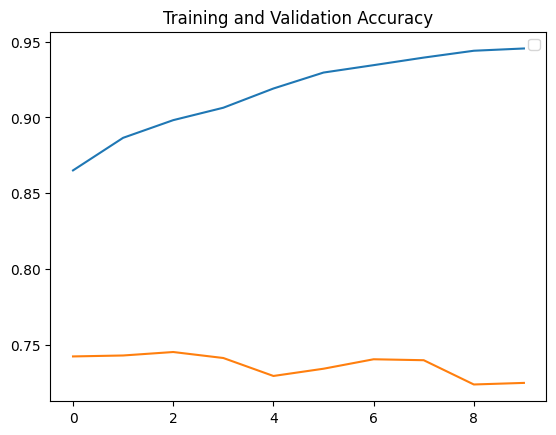

In [48]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Training and Validation Accuracy')
plt.legend()  # Show legend

plt.show()

# check sentiment analysis

It is to apply the trained model to new text sequences and obtain sentiment predictions for each sequence. It demonstrates how to preprocess the new text data using the same tokenizer and padding techniques used during training. The predicted sentiment is then determined based on the highest probability class predicted by the model.

In [50]:

# Given text sequences
texts = [
    "Sooo SAD I will miss you here in San Diego!!!",
    "I`d have responded, if I were going",
    "Shanghai is also really exciting (precisely -- skyscrapers galore). Good tweeps in China:  (SH)  (BJ)."
]

# Preprocess the texts
new_text_seqs = tokenizer.texts_to_sequences(texts)
new_text_padded = pad_sequences(new_text_seqs, padding='post', maxlen=35)  # Use the max_len determined during training

# Predict sentiment for each text
for i, text in enumerate(texts):
    prediction = model.predict(np.array([new_text_padded[i]]))
    predicted_class_index = prediction.argmax(axis=-1)
    if predicted_class_index[0] == 0:
        print(f"Prediction {i + 1}: Positive Sentiment")
    elif predicted_class_index[0] == 1:
        print(f"Prediction {i + 1}: Negative Sentiment")
    else:
        print(f"Prediction {i + 1}: Neutral Sentiment")


1/1 [==============================] - 0s 39ms/step
Prediction 1: Negative Sentiment
1/1 [==============================] - 0s 37ms/step
Prediction 2: Neutral Sentiment
1/1 [==============================] - 0s 54ms/step
Prediction 3: Positive Sentiment
